In [6]:
from sklearn.model_selection import cross_val_score
import numpy as np

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, \
    recall_score, f1_score, auc, precision_recall_curve
import numpy as np

import inspect
from sklearn.utils import all_estimators

import logging
import pandas as pd


In [4]:
def report_error_bin(clf, X, y, cv=5):
    """
    Evaluates a binary classification model using cross-validation.
    
    Parameters:
    - clf: The classifier model (must have fit and predict_proba methods).
    - X: Feature matrix (pandas DataFrame or numpy array).
    - y: Target vector (binary labels).
    - cv: Number of cross-validation folds (default=5).
    
    Returns:
    - dict: Dictionary with mean scores for accuracy, 
    precision, recall, f1, and pr_auc.
    """
    np.random.seed(42)
    # Standard metrics
    scores = cross_validate(
        clf, X, y, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'])
    
    # PR-AUC requires probabilities, so compute manually
    pr_aucs = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        clf.fit(X_train, y_train)
        y_proba = clf.predict_proba(X_test)[:, 1]  # Probability for positive class
        
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_aucs.append(auc(recall, precision))
    
    result = {
        'accuracy': np.mean(scores['test_accuracy']),
        'precision': np.mean(scores['test_precision']),
        'recall': np.mean(scores['test_recall']),
        'f1': np.mean(scores['test_f1']),
        'pr_auc': np.mean(pr_aucs)
    }
    
    return result

## Build list of models
Build list of models from scipy that do not need parameter tuning to train. 

In [18]:
logging.basicConfig(
    filename='model_reg2.log',
    filemode='w',  # overwrite each run ('a' to append)
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

def can_instantiate(cls):
    """Return True if cls can be instantiated with no required args."""
    try:
        sig = inspect.signature(cls)
        for param in sig.parameters.values():
            if (
                param.default is inspect._empty
                and param.kind in (
                    inspect.Parameter.POSITIONAL_ONLY,
                    inspect.Parameter.POSITIONAL_OR_KEYWORD,
                    inspect.Parameter.KEYWORD_ONLY,
                )
            ):
                return False
        return True
    except Exception as e:
        logging.warning(f'Failed to inspect {cls}: {e}')
        return False


def build_model_registry():
    models = {}
    failed_models = {}

    for name, cls in all_estimators(type_filter='classifier'):
        if can_instantiate(cls):
            try:
                models[name] = {
                    'model': cls(),
                    'binary': True,
                }
            except Exception as e:
                logging.error(f'Failed to instantiate classifier {name}: {e}')
        else:
            failed_models[name] = cls

    for name, cls in all_estimators(type_filter='regressor'):
        if can_instantiate(cls):
            try:
                models[name] = {
                    'model': cls(),
                    'binary': False,
                }
            except Exception as e:
                logging.error(f'Failed to instantiate regressor {name}: {e}')
        else:
            failed_models[name] = cls

    return models, failed_models


models, failed_models = build_model_registry()

# --- logging instead of print ---
logging.info(f'{len(models)} models loaded')
for x in models.keys():
    logging.info(f'LOADED: {x}')

logging.info('---')
logging.info(f'---{len(failed_models)} models failed to load')
for x in failed_models.keys():
    logging.info(f'FAILED: {x}')

In [7]:
df1_sel = pd.read_csv("data/processed/df1_sel.csv")
df2_sel = pd.read_csv("data/processed/df2_sel.csv")
df_sub = pd.read_csv("data/processed/df_sub.csv")

In [17]:
def _get_reg_cols(df, s):
    """ Helper function to get cols in a df that contain substring s. """
    return [col for col in df.columns if s in col]

for x in _get_reg_cols(df1_sel, 'Reading'):
    print(x)
 
print('---')   
for x in _get_reg_cols(df2_sel, 'Reading'):
    print(x)

Reading Quiz 2025-01-08
Reading Quiz 2025-01-10
Reading Quiz 2025-01-13
Reading Quiz 2025-01-15
Reading Quiz 2025-01-17
Reading Quiz 2025-01-22
Reading Quiz 2025-01-24
Reading Quiz 2025-01-27
Reading Quiz 2025-01-29
Reading Quiz 2025-01-31
Reading Quiz 2025-02-03
Reading Quiz 2025-02-05
Reading Quiz 2025-02-07
Reading Quiz 2025-02-10
Reading Quiz 2025-02-12
Reading Quiz 2025-02-14
Reading Quiz 2025-02-19
Reading Quiz 2025-02-21
Reading Quiz 2025-02-24
Reading Quiz 2025-02-26
Reading Quiz 2025-02-28
Reading Quiz 2025-03-03
Reading Quiz 2025-03-05
Reading Quiz 2025-03-07
Reading Quiz 2025-03-10
---
Reading Quiz 02
Reading Quiz 03
Reading Quiz 04
Reading Quiz 05
Reading Quiz 06
Reading Quiz 07
Reading Quiz 08
Reading Quiz 09
Reading Quiz 10
Reading Quiz 11
Reading Quiz 12
Reading Quiz 13
Reading Quiz 14
Reading Quiz 15
Reading Quiz 16
Reading Quiz 17
Reading Quiz 18
Reading Quiz 19
Reading Quiz 20
Reading Quiz 21
Reading Quiz 22
Reading Quiz 23
Reading Quiz 24
Reading Quiz 25
Reading Quiz

In [ ]:
import warnings

warnings.filterwarnings("ignore")

def get_results_dict(
    models, 
    df,
    error_fn=report_error_bin, 
    metrics=['accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
    response_col='atrisk',
    ):
    
    """ Evaluates each model in the registry using the provided error function 
        and returns a results dictionary.
        
        Parameters:
            - models (dict): A dictionary of models to evaluate.
            - df (pandas.DataFrame): The dataframe containing the data.
            - error_fn (function): The error function to use for evaluation.
            - metrics (list): A list of metrics to calculate.
            - response_col (str): The column name for the response variable.
        Returns:
            - results (dict): A dictionary w the results for each model.
        """
    results = {}

    # Columns will be sorted. Grab RQ columns.
    rq_cols = _get_reg_cols(df, 'Reading')
    logging.info(f"Found {len(rq_cols)} RQ columns")

    for model_name, info in models.items():
        logging.info(f"Evaluating {model_name}...")
        
        results[model_name] = {k: [] for k in metrics}
        results[model_name]['x'] = []

        for k in range(1, len(rq_cols) + 1):
            X = df[rq_cols[:k]]
            y = df[response_col]

            try:
                per_k_results = error_fn(
                    clf=info['model'],
                    X=X,
                    y=y
                )

            except Exception:
                logging.exception(
                    f"Error evaluating {model_name} with {k} RQs "
                    f"(X shape={X.shape}, y shape={y.shape})"
                )
                continue

            # log success at a lower verbosity if you want
            logging.debug(
                f"{model_name} | k={k} | results={per_k_results}"
            )

            for key, value in per_k_results.items():
                results[model_name][key].append(value)
                print(model_name, key, value, k)

            results[model_name]['x'].append(k)

    logging.info("Finished evaluating all models")
    return results

In [ ]:
models_bin = list(models.keys())

{'AdaBoostClassifier': {'model': AdaBoostClassifier(), 'binary': True},
 'BaggingClassifier': {'model': BaggingClassifier(), 'binary': True},
 'BernoulliNB': {'model': BernoulliNB(), 'binary': True},
 'CalibratedClassifierCV': {'model': CalibratedClassifierCV(), 'binary': True},
 'CategoricalNB': {'model': CategoricalNB(), 'binary': True},
 'ClassifierChain': {'model': ClassifierChain(), 'binary': True},
 'ComplementNB': {'model': ComplementNB(), 'binary': True},
 'DecisionTreeClassifier': {'model': DecisionTreeClassifier(), 'binary': True},
 'DummyClassifier': {'model': DummyClassifier(), 'binary': True},
 'ExtraTreeClassifier': {'model': ExtraTreeClassifier(), 'binary': True},
 'ExtraTreesClassifier': {'model': ExtraTreesClassifier(), 'binary': True},
 'GaussianNB': {'model': GaussianNB(), 'binary': True},
 'GaussianProcessClassifier': {'model': GaussianProcessClassifier(),
  'binary': True},
 'GradientBoostingClassifier': {'model': GradientBoostingClassifier(),
  'binary': True},
 '

## Run Classification

The code below takes a while to run so has been commented out.

In [71]:
# results1_bin = get_results_dict(
#     models=models_bin,
#     df=df1_sel,
# )

In [72]:
# results2_bin = get_results_dict(
#     models=models_bin,
#     df=df2_sel,
# )

## Save/Load Pickles

In [19]:
import pickle

# SAVE
# with open('out/pickles/results1_bin.pkl', 'wb') as f:
#     pickle.dump(results1_bin, f)
    
# with open('out/pickles/results1_reg.pkl', 'wb') as f:
#     pickle.dump(results1_reg, f)
    
# with open('out/pickles/results2_bin.pkl', 'wb') as f:
#     pickle.dump(results2_bin, f)
    
# with open('out/pickles/results2_reg.pkl', 'wb') as f:
#     pickle.dump(results2_reg, f)
    
    
# # LOAD
with open('out/pickles/results1_bin-57.pkl', 'rb') as f:
    results1_bin = pickle.load(f)

# with open('out/pickles/results1_reg.pkl', 'rb') as f:
#     results1_reg = pickle.load(f)

with open('out/pickles/results2_bin-57.pkl', 'rb') as f:
    results2_bin = pickle.load(f)

# with open('out/pickles/results2_reg.pkl', 'rb') as f:
#     results2_reg = pickle.load(f)

## Plot All Models

5
models plotting:  dict_keys(['AdaBoostClassifier', 'BaggingClassifier', 'BernoulliNB', 'CalibratedClassifierCV', 'CategoricalNB', 'ClassifierChain', 'ComplementNB', 'DecisionTreeClassifier', 'ExtraTreeClassifier', 'ExtraTreesClassifier', 'GaussianProcessClassifier', 'GradientBoostingClassifier', 'HistGradientBoostingClassifier', 'LabelPropagation', 'LabelSpreading', 'LinearDiscriminantAnalysis', 'LinearSVC', 'LogisticRegression', 'LogisticRegressionCV', 'MLPClassifier', 'MultinomialNB', 'NearestCentroid', 'NuSVC', 'PassiveAggressiveClassifier', 'Perceptron', 'QuadraticDiscriminantAnalysis', 'RadiusNeighborsClassifier', 'RandomForestClassifier', 'RidgeClassifier', 'RidgeClassifierCV', 'SGDClassifier', 'SVC', 'SelfTrainingClassifier'])
Handles: 46, Labels: 46
AdaBoostClassifier Q1
BaggingClassifier Q1
BernoulliNB Q1
CalibratedClassifierCV Q1
CategoricalNB Q1
ComplementNB Q1
DecisionTreeClassifier Q1
ExtraTreeClassifier Q1
ExtraTreesClassifier Q1
GaussianProcessClassifier Q1
GradientBoo

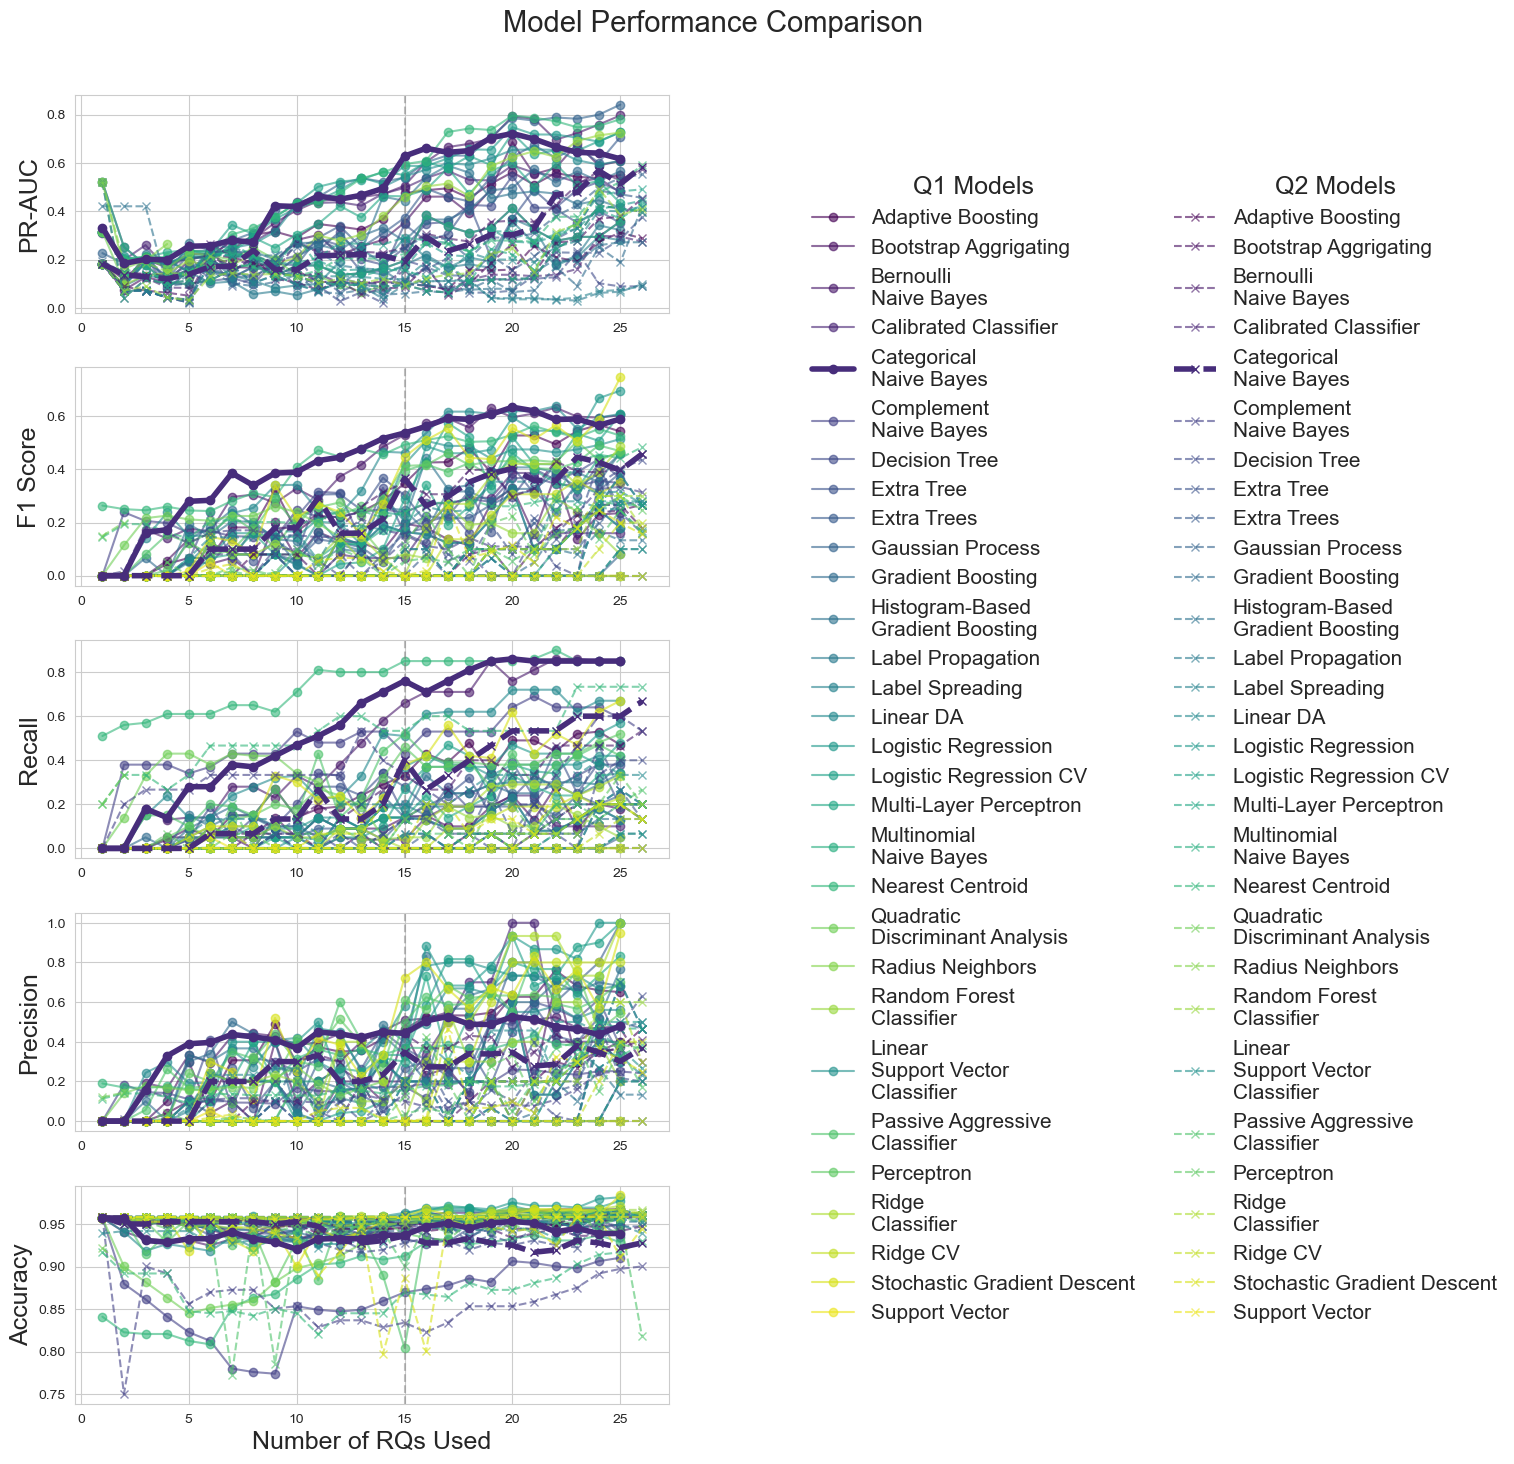

In [76]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D

import seaborn as sns
sns.set_style("whitegrid")

model_name_dict = {
    "CategoricalNB": "Categorical\nNaive Bayes",
    "NearestCentroid": "Nearest Centroid",
    "Linear DA": "Linear DA",
    "AdaBoost": "Adaptive Boosting",
    "BernoulliNB": "Bernoulli\nNaive Bayes",
    "LogisticRegression": "Logistic Regression",
    "GaussianProcess": "Gaussian Process",
    "LogisticRegressionCV": "Logistic Regression CV",
    "CalibratedCV": "Calibrated Classifier",
    "GaussianNB": "Gaussian\nNaive Bayes",
    "RandomForest": "Random Forest\nClassifier",
    "QuadraticDiscriminantAnalysis": "Quadratic DA",
    "MLP": "Multi-Layer Perceptron",
    "HistGradientBoosting": "Histogram-Based\nGradient Boosting",
    "KNeighbors": "K-Nearest Neighbors (KNN)",
    "ExtraTrees": "Extra Trees",
    "Bagging": "Bootstrap Aggrigating",
    "GradientBoosting": "Gradient Boosting",
    "DecisionTree": "Decision Tree",
    "LabelSpreading": "Label Spreading",
    "ExtraTree": "Extra Tree",
    "LabelPropagation": "Label Propagation",
    "ComplementNB": "Complement\nNaive Bayes",
    "MultinomialNB": "Multinomial\nNaive Bayes",
    "Quadratic DA": "Quadratic\nDiscriminant Analysis",
    "RadiusNeighbors": "Radius Neighbors",
    "LinearSVC": "Linear\nSupport Vector\nClassifier",
    "PassiveAggressive": "Passive Aggressive\nClassifier",
    "Perceptron":"Perceptron",
    "Ridge": "Ridge\nClassifier",
    "RidgeClassifierCV": "Ridge Classifier CV",
    "RidgeCV": "Ridge CV",
    "SGD": "Stochastic Gradient Descent",
    "SVC": "Support Vector"
    
}

def plot_errors_gs(results1, results2, 
                errors=["pr_auc",   "f1", "recall", "precision", "accuracy"],
                ylabs=["PR-AUC", "F1 Score", "Recall", "Precision", "Accuracy"],
                special_model='CategoricalNB',
                ylim=None, threshold=None, 
                thresh_direction=None,
                limit_models_to=None,
                fontsize=5,
                figsize=(17, 17),
                width_ratios=[5, 2, 2],
                vline_at=15,
                limit=False):
    """
    Plot model errors with a dedicated GridSpec legend column.
    
    Parameters:
    - results1: Dictionary of results for the first dataset.
    - results2: Dictionary of results for the second dataset.
    - errors: List of error metrics to plot.
    - ylabs: List of y-axis labels corresponding to the error metrics.
    - special_model: Name of the model to highlight in the plots.
    - ylim: Dictionary specifying y-axis limits for each metric.
    - threshold: Dictionary specifying threshold values for each metric.
    - thresh_direction: Direction for threshold filtering ('higher' or 'lower').
    - limit_models_to: List of model names to include in the plots.
    - fontsize: Font size for labels and legend.
    - figsize: Tuple specifying the figure size.
    - width_ratios: List specifying the width ratios for the GridSpec layout.
    - vline_at: x-value at which to draw a vertical line across all plots (15 by default).
    - limit: Boolean to exclude certain models from the plots. These models
        are "GaussianNB", "DummyClassifier", and "KNeighborsClassifier". They 
        are not appropriate and heavily violate assumptions
    
    Output:
    - fig: Matplotlib figure 
    """

    fig = plt.figure(figsize=figsize)

    print(len(errors))
    # Main layout: plots on left, legend on right
    gs = gridspec.GridSpec(
        nrows=len(errors),
        ncols=3,
        width_ratios=width_ratios,
        wspace=0.35,
        hspace=0.25,
        figure=fig,
    )

    axes = [fig.add_subplot(gs[i, 0]) for i in range(len(errors))]
    
    legend_ax1 = fig.add_subplot(gs[:, 1])
    legend_ax2 = fig.add_subplot(gs[:, 2])
    
    legend_ax1.axis("off")
    legend_ax2.axis("off")

    cmap = plt.get_cmap("viridis")
    
    if limit_models_to:
        results1 = {k: v for k, v in results1.items() if k in limit_models_to}
        results2 = {k: v for k, v in results2.items() if k in limit_models_to}
        
    if limit:
        results1 = {k: v for k, v in results1.items() if k != "GaussianNB" and k != "DummyClassifier" and k != "KNeighborsClassifier"}
        results2 = {k: v for k, v in results2.items() if k != "GaussianNB" and k != "DummyClassifier" and k != "KNeighborsClassifier"}
    
    print('models plotting: ', results1.keys())
    models = sorted(set(results1.keys()) | set(results2.keys())) 
        
    color_array = cmap(np.linspace(0, 1, len(models)))
    colors = {model: color for model, color in zip(models, color_array)}

    def add_errors_to_plot(results, line_type, marker, dataset_label):
        for model, info in results.items():
            for i, metric in enumerate(errors):

                ax = axes[i]

                x = info["x"]
                y = info[metric]
                
                if threshold and thresh_direction == "higher":
                    try:
                        if max(y) < threshold[metric]:
                            continue
                    except Exception:
                        pass
                    
                if threshold and thresh_direction == "lower":
                    try:
                        if min(y) > threshold[metric]:
                            continue
                    except Exception:
                        pass

                if len(y) == 0:
                    continue

                if len(x) != len(y):
                    print(
                        f"Warning: length mismatch for {model} on {metric} "
                        f"(x: {len(x)}, y: {len(y)})"
                    )
                    x = x[:len(y)]
                    
                is_special = model == special_model
                line, = ax.plot(
                    x, y,
                    marker=marker,
                    label=f"{model} {dataset_label}",
                    linestyle=line_type,
                    color=colors[model],
                    linewidth=4 if is_special else 1.5,
                    zorder=10 if is_special else 1,
                    alpha=1.0 if is_special else 0.6
                )

                # x and y labels only on leftmost plots
                ax.set_ylabel(ylabs[i], fontsize=fontsize+3)
                if i == len(errors) - 1:
                    ax.set_xlabel("Number of RQs Used", fontsize=fontsize+3)
                else:
                    ax.set_xlabel("")

                if ylim and metric in ylim:
                    ax.set_ylim(ylim[metric])
                    
                ax.grid(True)



    add_errors_to_plot(results1, line_type="-", marker="o", dataset_label="Q1")
    add_errors_to_plot(results2, line_type="--", marker="x", dataset_label="Q2")

    # Build legend manually from model colors
    # Get one handle per model
    handles1 = []
    handles2 = []
    
    labels1 = []
    labels2 = []
    
    seen = set()

    def process_label(label):
        """ Text processing to make model names more readable in the legend."""
        label = label.replace(" Q1", "").replace(" Q2", "")
        label = label.replace("Classifier", "")
        # label = label.replace("DiscriminantAnalysis", "\nDiscriminantAnalysis")
        label = label.replace("DiscriminantAnalysis", " DA")
        
        return label.strip()

    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        print(f"Handles: {len(h)}, Labels: {len(l)}")
        for handle, label in zip(h, l):
            if label not in seen:
                if "Q1" in label:
                    print(label)
                    handles1.append(handle)
                    lab = model_name_dict[process_label(label)]
                    labels1.append(lab)
                elif "Q2" in label:
                    handles2.append(handle)
                    lab = model_name_dict[process_label(label)]
                    labels2.append(lab)
                seen.add(label)

        if vline_at:
            ax.axvline(vline_at, color='gray', linestyle='--', alpha=0.5)

        
    print(f"Length of handles1: {len(handles1)}, Length of labels1: {len(labels1)}")
    # print(f"Length of handles2: {len(handles2)}, Length of labels2: {len(labels2)}")
    # Split legend into two columns manually

    legend_ax1.legend(
        handles1,
        labels1,
        loc="center left",
        frameon=False,
        fontsize=fontsize,
        title_fontsize=fontsize+3,
        title="Q1 Models"
    )

    legend_ax2.legend(
        handles2,
        labels2,
        loc="center left",
        frameon=False,
        fontsize=fontsize,
        title_fontsize=fontsize+3,
        title="Q2 Models"
    )
    
    fig.suptitle(
        "Model Performance Comparison",
        fontsize=fontsize+6,
        y=0.93
    )

    return fig

binary_errors = ["pr_auc",  "precision", "f1", "recall", "accuracy" ]

f = plot_errors_gs(
    results1_bin,
    results2_bin,
    fontsize=15,
    limit=True
)

plt.tight_layout()
plt.savefig("out/model_comparison_binary_full_long_gs-57.svg")
plt.savefig("out/model_comparison_binary_full_long_gs-57.png")
plt.show()

## Plot Top PR-AUC models

In [35]:
def rank_df_based_on_metric(
    quarter="Q1",
    metric="pr_auc",
    rqs=15,
):
    results = results1_bin if quarter == "Q1" else results2_bin
    ranked_df = []

    for model, info in results.items():
        try:
            metric_at_k = info[metric][rqs - 1]  # rqs-1 because of 0-indexing
        except IndexError:
            print(f"{model}: Not enough data points to get {metric} at {rqs} RQs")
            metric_at_k = 0
        ranked_df.append({'model': model, f'{metric}_at_{rqs}_RQs': metric_at_k})
    
    ranked_df = pd.DataFrame(ranked_df).sort_values(by=f'{metric}_at_{rqs}_RQs', ascending=False)
    return ranked_df


def filter_models_by_threshold(df, limits, rqs=15):
    """ Filters the DataFrame of models based on specified metric thresholds."""
    
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'pr_auc']
    models = list(results1_bin.keys())

    dfs = {}
    for metric in metrics:
        dfs[metric] = rank_df_based_on_metric(metric=metric, quarter="Q1", rqs=15)
    full_df = dfs[metrics[0]]
    for i in range(1, len(metrics)):
        full_df = full_df.merge(dfs[metrics[i]], on='model')
        
    for metric, threshold in limits.items():
        df = df[df[f'{metric}_at_{rqs}_RQs'] >= threshold]

    return df

ClassifierChain: Not enough data points to get pr_auc at 15 RQs
LinearSVC: Not enough data points to get pr_auc at 15 RQs
NuSVC: Not enough data points to get pr_auc at 15 RQs
PassiveAggressiveClassifier: Not enough data points to get pr_auc at 15 RQs
Perceptron: Not enough data points to get pr_auc at 15 RQs
QuadraticDiscriminantAnalysis: Not enough data points to get pr_auc at 15 RQs
RadiusNeighborsClassifier: Not enough data points to get pr_auc at 15 RQs
RidgeClassifier: Not enough data points to get pr_auc at 15 RQs
RidgeClassifierCV: Not enough data points to get pr_auc at 15 RQs
SGDClassifier: Not enough data points to get pr_auc at 15 RQs
SVC: Not enough data points to get pr_auc at 15 RQs
SelfTrainingClassifier: Not enough data points to get pr_auc at 15 RQs
5
models plotting:  dict_keys(['CategoricalNB', 'GaussianProcessClassifier', 'LinearDiscriminantAnalysis', 'LogisticRegression', 'NearestCentroid'])
Handles: 10, Labels: 10
CategoricalNB Q1
GaussianProcessClassifier Q1
Lin

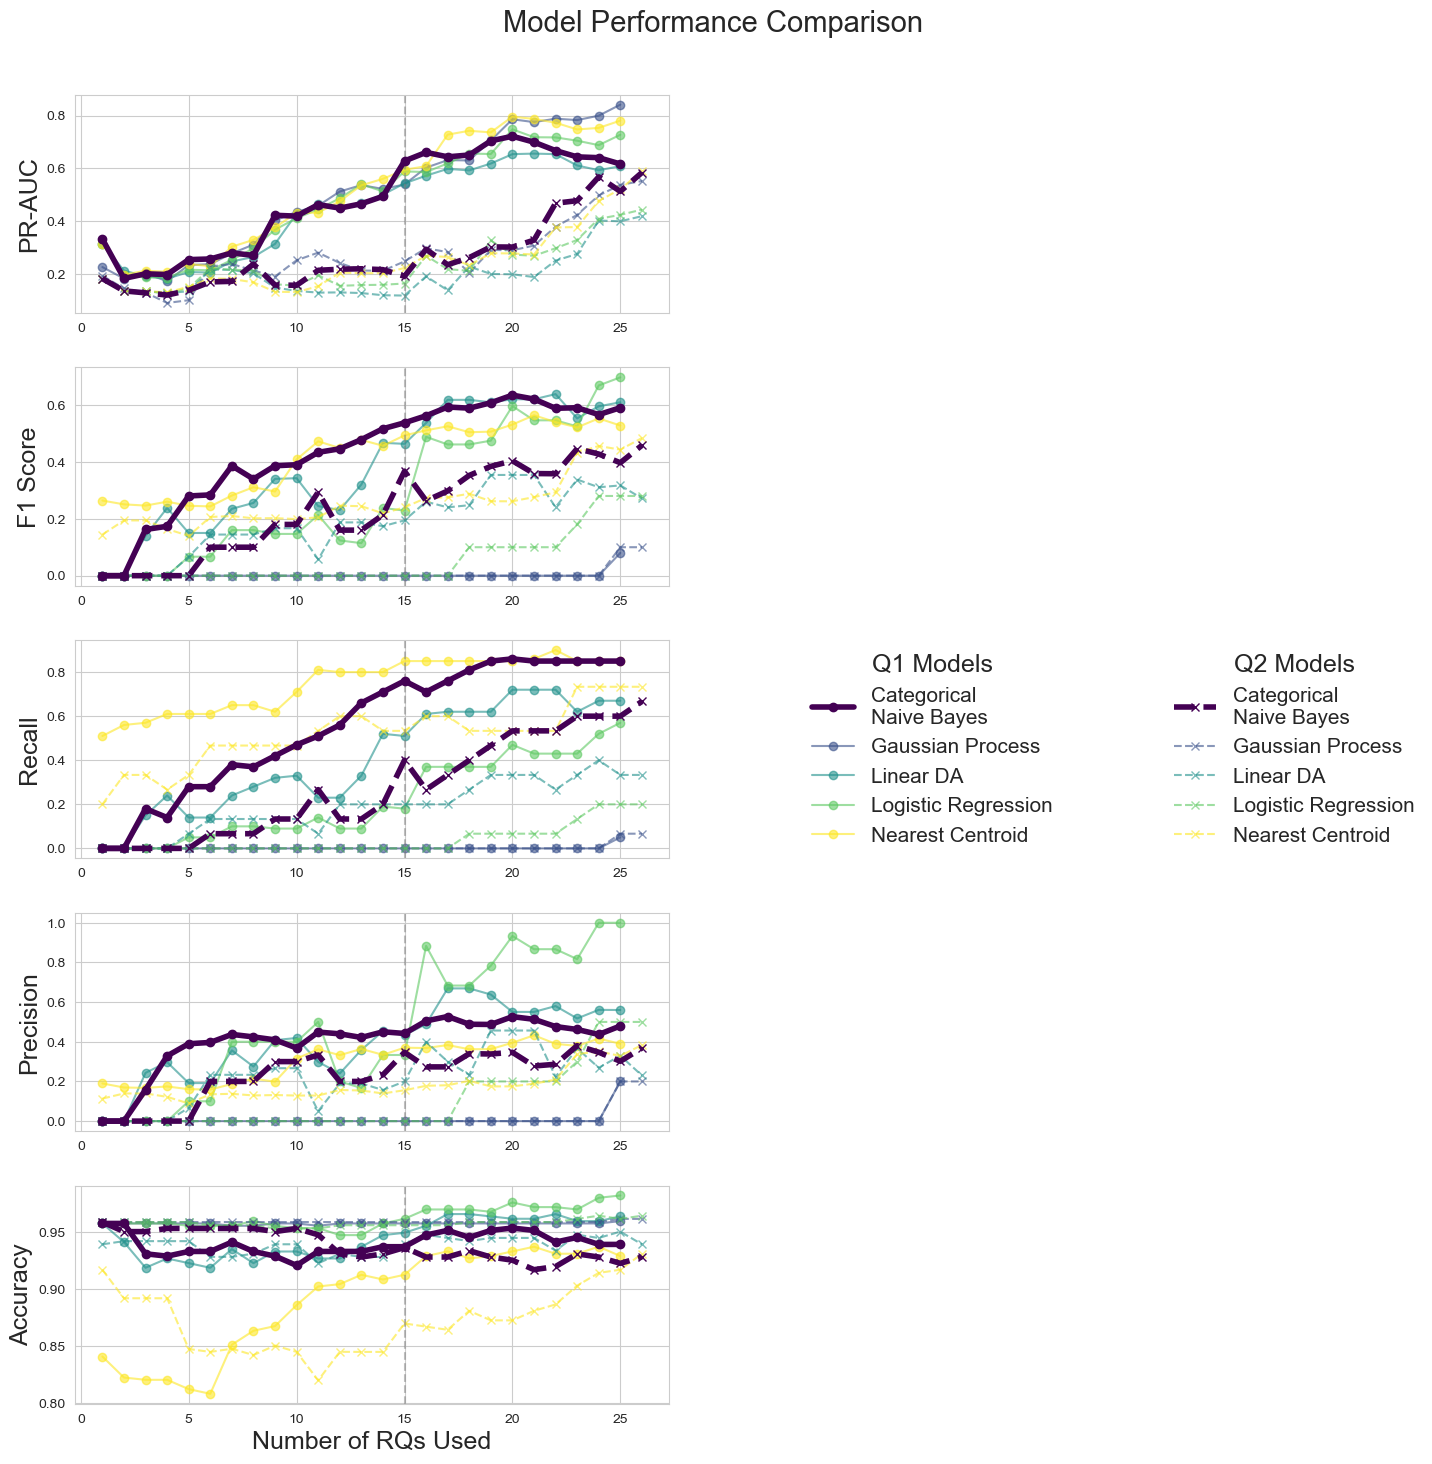

In [75]:
ranked_df = rank_df_based_on_metric()

# Redundant, no need to report
ranked_df = ranked_df[~(ranked_df['model'] == 'LogisticRegressionCV')]

# Need to take top 6 since GaussianNB is in top 5 but violates assumptions too heavily so remove
pr_auc_top = ranked_df['model'].to_list()[:6]
pr_auc_top

f = plot_errors_gs(
    results1_bin,
    results2_bin,
    fontsize=15,
    limit=True,
    limit_models_to=pr_auc_top
)

# -cln = clean, with appropriate models included
f.savefig('out/model_comparison/binary_top_pr_auc_15_rqs-57-cln.png', dpi=300)
f.savefig('out/model_comparison/binary_top_pr_auc_15_rqs-57-cln.svg', dpi=300)